# Music Genre Classification: Macro-Genre Construction Through Agglomerative Clustering

This notebook documents our methodology for constructing macro-genre groupings from Spotify's 82 fine-grained genres. We use a **hybrid approach** combining:

1. **Data-driven clustering** - Hierarchical clustering on genre feature centroids
2. **Feature separability analysis** - Identifying discriminative features per genre
3. **Domain knowledge** - Assigning interpretable labels to clusters

This approach follows standard practice in applied ML for categorical aggregation.

## 1. Setup and Data Loading

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.feature_selection import mutual_info_classif
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [32]:
# Load preprocessed dataset
data = pd.read_csv("../../data/processed/spotify_features.csv")

print(f"Dataset shape: {data.shape}")
print(f"Total genres: {data['genre'].nunique()}")
data.head()

Dataset shape: (1159748, 14)
Total genres: 82


,track_name,artist_name,genre,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_sec,popularity
0,I Won't Give Up,Jason Mraz,acoustic,-0.295121,-1.244639,-1.178954,1.049226,-0.691216,-0.537222,-0.393524,0.403917,-0.189488,-0.062859,3.123384
1,93 Million Miles,Jason Mraz,acoustic,0.187328,-0.686411,0.221331,0.437937,-0.691179,-0.624753,-0.528338,0.631455,-0.229613,-0.221997,1.990284
2,Do Not Let Me Go,Joshua Hyslop,acoustic,-0.696259,-1.499723,-1.156609,0.046373,-0.691079,-0.664042,-0.477093,0.619702,-0.832373,-0.606319,2.430934
3,Fast Car,Boyce Avenue,acoustic,-0.788412,-1.436876,0.195262,1.367548,-0.691216,-0.712781,-0.445557,2.806734,-0.152002,0.366301,2.493884
4,Sky's Still Blue,Andrew Belle,acoustic,-0.582422,0.559434,-0.888469,-0.701259,-0.638350,-0.562088,-0.493649,1.695337,0.626921,-0.035059,2.242084


In [33]:
# Define audio features for analysis
feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness', 'popularity'
]

print(f"Features: {len(feature_cols)}")
print(feature_cols)

Features: 10
['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'loudness', 'popularity']


## 2. The Problem: 82 Genres Are Too Many

Let's first examine why classifying 82 fine-grained genres is problematic with audio features alone.

In [34]:
# Genre distribution
genre_counts = data['genre'].value_counts()

print(f"Genre with most samples: {genre_counts.idxmax()} ({genre_counts.max():,})")
print(f"Genre with least samples: {genre_counts.idxmin()} ({genre_counts.min():,})")
print(f"\nClass imbalance ratio: {genre_counts.max() / genre_counts.min():.1f}x")

Genre with most samples: black-metal (21,837)
Genre with least samples: songwriter (589)

Class imbalance ratio: 37.1x


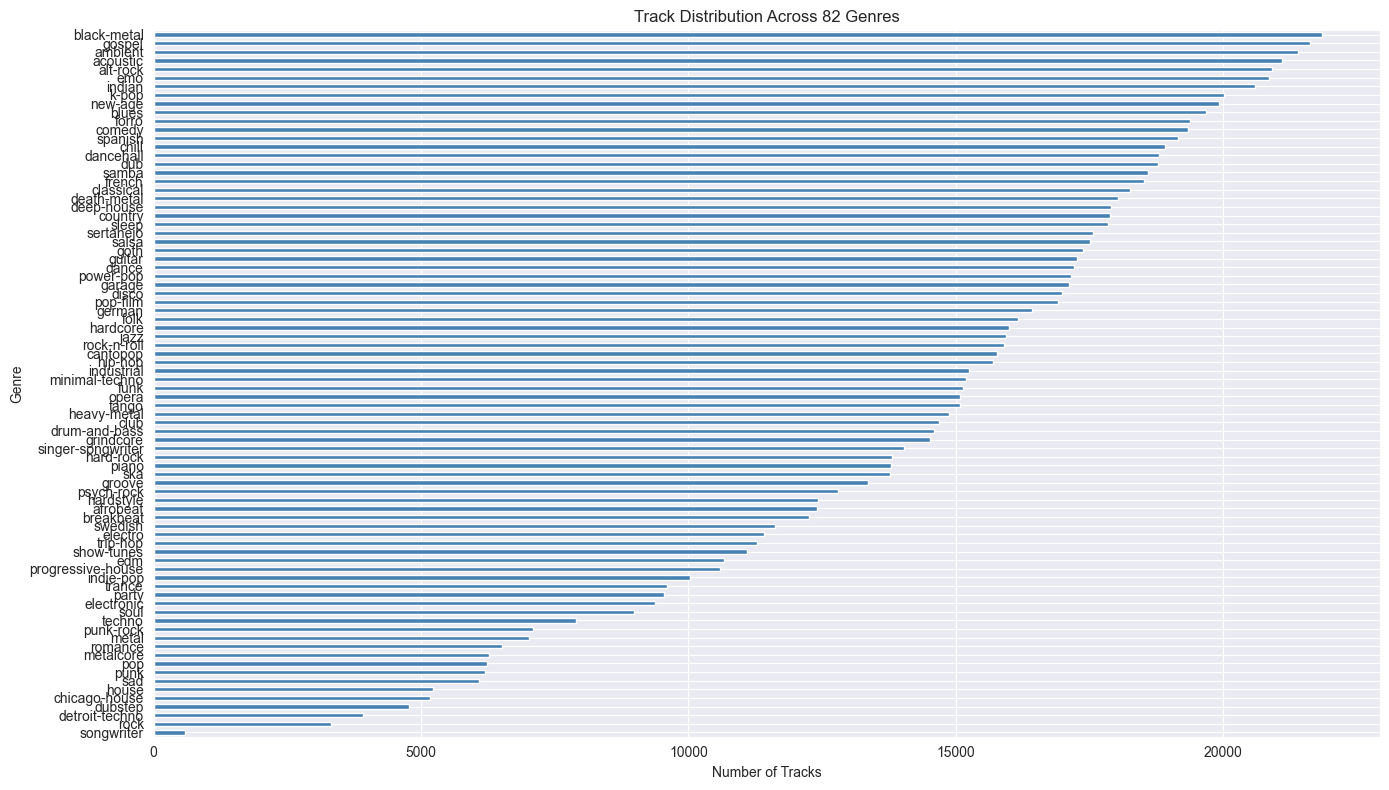

In [35]:
# Visualize genre distribution
plt.figure(figsize=(14, 8))
genre_counts.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Number of Tracks')
plt.ylabel('Genre')
plt.title('Track Distribution Across 82 Genres')
plt.tight_layout()
plt.show()

In [36]:
# Baseline: Try classifying top 20 genres
top_n = 20
top_genres = genre_counts.head(top_n).index.tolist()
X_filtered = data[data['genre'].isin(top_genres)].copy()

X_feat = X_filtered[feature_cols].values
le = LabelEncoder()
y_labels = le.fit_transform(X_filtered['genre'])

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = SGDClassifier(loss='hinge', class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)

acc = accuracy_score(y_test, clf.predict(X_test_s))
print(f"Baseline accuracy with {top_n} genres: {acc:.2%}")
print("\nThis low accuracy demonstrates that fine-grained genres are not separable with audio features alone.")

Baseline accuracy with 20 genres: 24.12%

This low accuracy demonstrates that fine-grained genres are not separable with audio features alone.


## 3. Hierarchical Clustering of Genre Centroids

To identify natural genre groupings, we compute the **centroid** (mean feature vector) for each genre and apply **hierarchical clustering**. This is a fully data-driven approach that reveals which genres are acoustically similar.

In [37]:
# Calculate mean features for each genre (centroid)
genre_centroids = data.groupby('genre')[feature_cols].mean()

print(f"Genre centroids shape: {genre_centroids.shape}")
genre_centroids.head(10)

Genre centroids shape: (82, 10)


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,popularity
genre,,,,,,,,,,
acoustic,-0.011543,-0.782881,-0.095234,0.711814,-0.279406,-0.229417,-0.344025,-0.098225,-0.257548,-0.035126
afrobeat,0.624160,0.199877,0.893555,-0.133222,0.039469,-0.192922,-0.014667,-0.076707,0.152448,-0.618364
alt-rock,-0.190242,0.370729,-0.006701,-0.525180,-0.467605,-0.086724,-0.251140,0.163450,0.485242,1.272453
ambient,-1.127528,-1.391737,-1.105589,1.147153,1.408871,-0.386582,-0.336537,-0.454533,-1.805471,0.102335
black-metal,-1.476989,0.720026,-1.127401,-0.733099,0.804910,0.117482,-0.014487,0.125360,0.340950,-0.459562
blues,-0.082645,0.021459,0.392307,-0.038246,-0.371856,0.148354,-0.243563,0.012590,0.183022,0.203767
breakbeat,0.762856,0.760681,0.096234,-0.841321,0.668930,-0.128555,-0.069502,0.359915,0.497392,-0.892626
cantopop,0.062216,-0.443334,-0.142057,0.440960,-0.679596,0.073874,-0.323713,0.038437,-0.022684,-0.361893
chicago-house,1.283871,0.401497,0.427926,-0.814917,0.747115,-0.418986,-0.133237,0.122535,0.048482,-0.951964


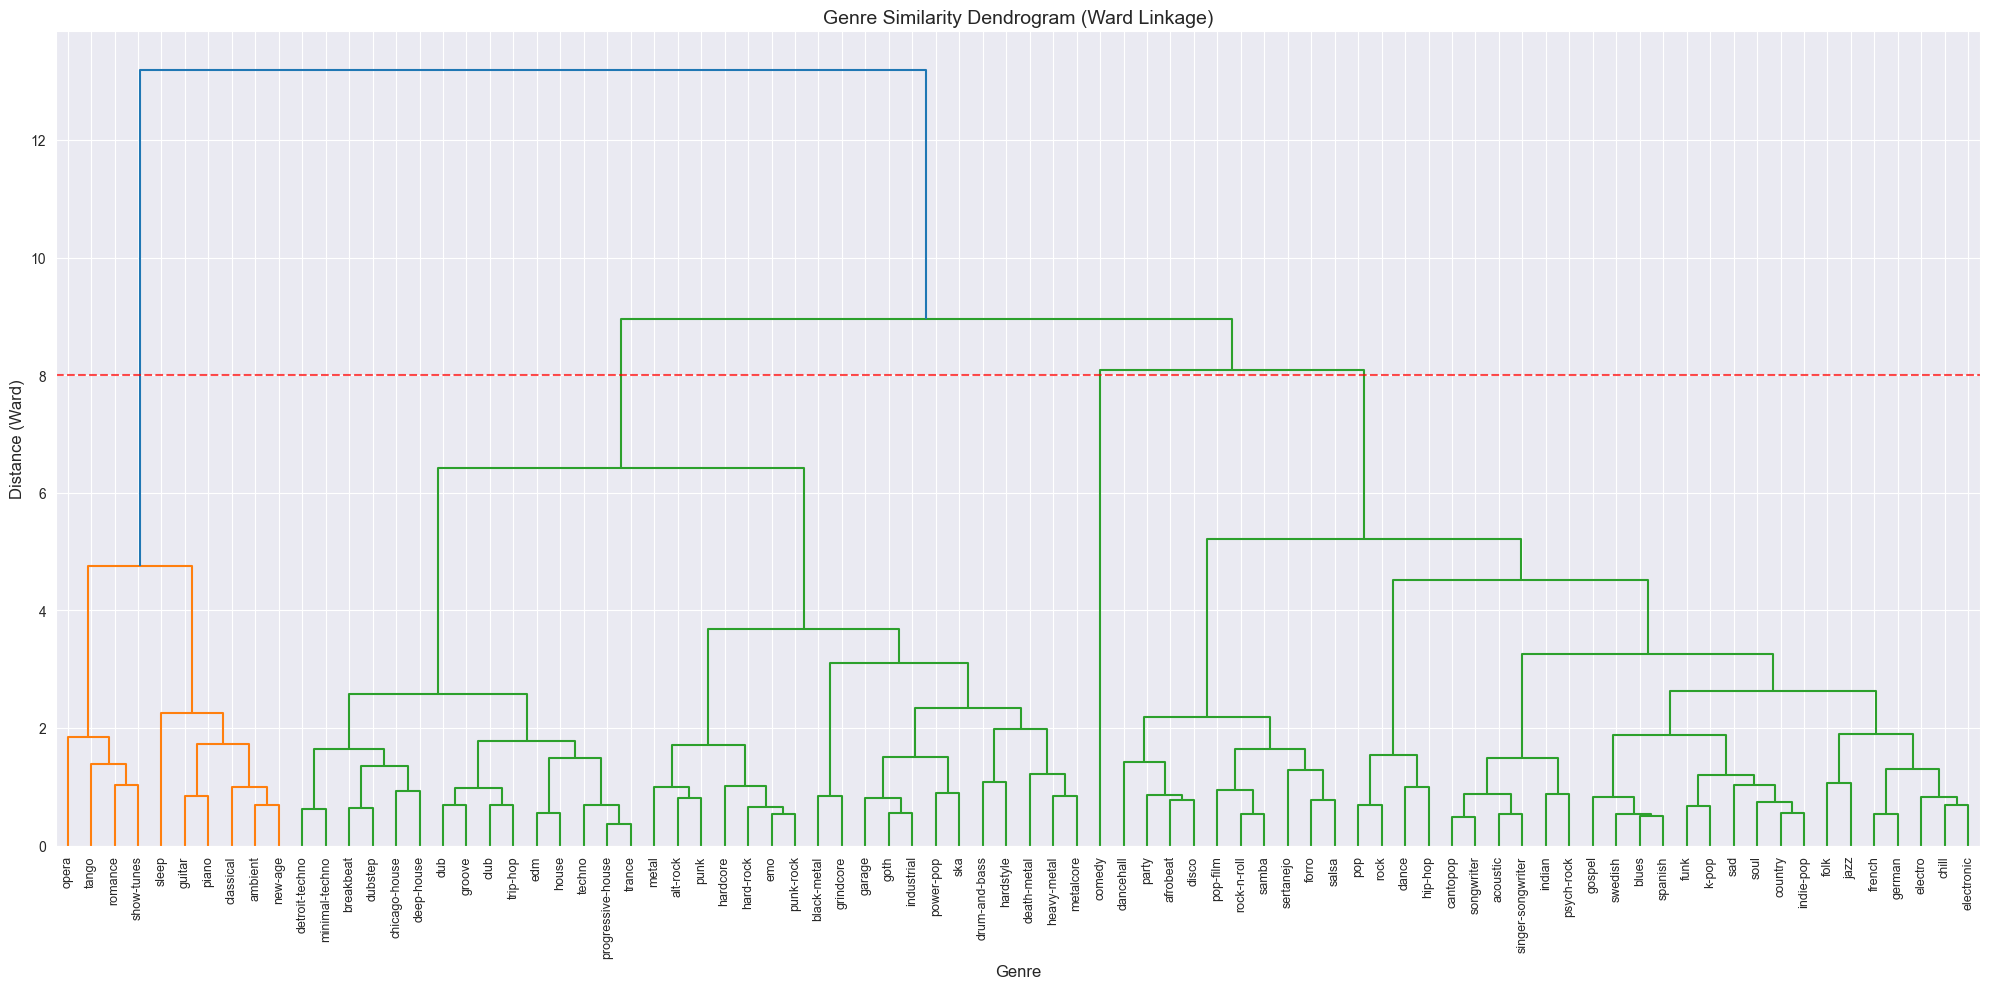


The dendrogram shows natural groupings. Genres that merge at low distances are acoustically similar.


In [38]:
# Hierarchical clustering using Ward's method
linkage_matrix = linkage(genre_centroids, method='ward')

# Plot dendrogram
plt.figure(figsize=(20, 10))
dendrogram(
    linkage_matrix,
    labels=genre_centroids.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=9
)
plt.title("Genre Similarity Dendrogram (Ward Linkage)", fontsize=14)
plt.ylabel("Distance (Ward)", fontsize=12)
plt.xlabel("Genre", fontsize=12)
plt.axhline(y=8, color='r', linestyle='--', alpha=0.7, label='Cut threshold')
plt.tight_layout()
plt.show()

print("\nThe dendrogram shows natural groupings. Genres that merge at low distances are acoustically similar.")

In [39]:
# Cut dendrogram into 10 clusters
n_clusters = 10
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

genre_to_cluster = pd.DataFrame({
    'genre': genre_centroids.index,
    'cluster': cluster_labels
}).sort_values('cluster')

print(f"AUTOMATIC CLUSTERING INTO {n_clusters} GROUPS")
print("="*60)

for c in range(1, n_clusters + 1):
    genres_in_cluster = genre_to_cluster[genre_to_cluster['cluster'] == c]['genre'].tolist()
    print(f"\nCluster {c} ({len(genres_in_cluster)} genres):")
    print(f"  {', '.join(genres_in_cluster[:])}")

AUTOMATIC CLUSTERING INTO 10 GROUPS

Cluster 1 (4 genres):
  opera, tango, romance, show-tunes

Cluster 2 (6 genres):
  guitar, ambient, sleep, new-age, piano, classical

Cluster 3 (15 genres):
  dub, trip-hop, minimal-techno, house, trance, dubstep, edm, detroit-techno, groove, progressive-house, club, chicago-house, breakbeat, deep-house, techno

Cluster 4 (7 genres):
  punk, punk-rock, hard-rock, emo, metal, hardcore, alt-rock

Cluster 5 (12 genres):
  power-pop, industrial, ska, heavy-metal, metalcore, hardstyle, goth, black-metal, garage, grindcore, death-metal, drum-and-bass

Cluster 6 (10 genres):
  afrobeat, sertanejo, samba, salsa, rock-n-roll, pop-film, disco, party, dancehall, forro

Cluster 7 (4 genres):
  pop, hip-hop, rock, dance

Cluster 8 (6 genres):
  indian, songwriter, cantopop, singer-songwriter, acoustic, psych-rock

Cluster 9 (17 genres):
  gospel, german, swedish, spanish, soul, folk, blues, country, k-pop, chill, french, funk, electro, sad, indie-pop, jazz, elec

In [40]:
# Show what the algorithm grouped together (before manual adjustments)
n_clusters = 10  # match your 10 macro-genres

cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

genre_to_cluster = pd.DataFrame({
    'genre': genre_centroids.index,
    'cluster': cluster_labels
}).sort_values('cluster')

print("AUTOMATIC CLUSTERING RESULTS (before manual adjustment)")
print("="*70)
print("Note: Some groupings are acoustically correct but musically nonsensical\n")

for c in range(1, n_clusters + 1):
    genres_in_cluster = genre_to_cluster[genre_to_cluster['cluster'] == c]['genre'].tolist()
    print(f"Cluster {c}: {', '.join(genres_in_cluster)}")

AUTOMATIC CLUSTERING RESULTS (before manual adjustment)
Note: Some groupings are acoustically correct but musically nonsensical

Cluster 1: opera, tango, romance, show-tunes
Cluster 2: guitar, ambient, sleep, new-age, piano, classical
Cluster 3: dub, trip-hop, minimal-techno, house, trance, dubstep, edm, detroit-techno, groove, progressive-house, club, chicago-house, breakbeat, deep-house, techno
Cluster 4: punk, punk-rock, hard-rock, emo, metal, hardcore, alt-rock
Cluster 5: power-pop, industrial, ska, heavy-metal, metalcore, hardstyle, goth, black-metal, garage, grindcore, death-metal, drum-and-bass
Cluster 6: afrobeat, sertanejo, samba, salsa, rock-n-roll, pop-film, disco, party, dancehall, forro
Cluster 7: pop, hip-hop, rock, dance
Cluster 8: indian, songwriter, cantopop, singer-songwriter, acoustic, psych-rock
Cluster 9: gospel, german, swedish, spanish, soul, folk, blues, country, k-pop, chill, french, funk, electro, sad, indie-pop, jazz, electronic
Cluster 10: comedy


## 4. Pairwise Genre Distance Analysis

We compute pairwise Euclidean distances between genre centroids to identify:
- **Most similar pairs**: Genres that should be merged
- **Most distant pairs**: Genres that are acoustically distinct

In [41]:
# Pairwise distance matrix
dist_matrix = pd.DataFrame(
    squareform(pdist(genre_centroids)),
    index=genre_centroids.index,
    columns=genre_centroids.index
)

# Find closest and farthest pairs
pairs = []
for g1 in dist_matrix.index:
    for g2 in dist_matrix.columns:
        if g1 < g2:
            pairs.append((g1, g2, dist_matrix.loc[g1, g2]))

print("TOP 20 MOST SIMILAR GENRE PAIRS (candidates for merging)")
print("="*60)
for g1, g2, dist in sorted(pairs, key=lambda x: x[2])[:20]:
    print(f"  {g1:20s} <-> {g2:20s} : {dist:.4f}")

TOP 20 MOST SIMILAR GENRE PAIRS (candidates for merging)
  progressive-house    <-> trance               : 0.3729
  cantopop             <-> songwriter           : 0.4901
  blues                <-> spanish              : 0.5091
  blues                <-> swedish              : 0.5115
  k-pop                <-> spanish              : 0.5119
  acoustic             <-> singer-songwriter    : 0.5362
  spanish              <-> swedish              : 0.5380
  rock-n-roll          <-> samba                : 0.5399
  french               <-> german               : 0.5416
  emo                  <-> punk-rock            : 0.5443
  goth                 <-> industrial           : 0.5531
  country              <-> indie-pop            : 0.5586
  edm                  <-> house                : 0.5614
  progressive-house    <-> techno               : 0.5659
  acoustic             <-> songwriter           : 0.5876
  hard-rock            <-> punk-rock            : 0.6005
  country              <-> k-po

In [42]:
print("\nTOP 20 MOST DISTANT GENRE PAIRS (naturally separable)")
print("="*60)
for g1, g2, dist in sorted(pairs, key=lambda x: x[2], reverse=True)[:20]:
    print(f"  {g1:20s} <-> {g2:20s} : {dist:.4f}")


TOP 20 MOST DISTANT GENRE PAIRS (naturally separable)
  comedy               <-> sleep                : 6.9133
  ambient              <-> comedy               : 6.8166
  classical            <-> comedy               : 6.7439
  comedy               <-> new-age              : 6.7384
  comedy               <-> pop                  : 6.6085
  comedy               <-> minimal-techno       : 6.5844
  comedy               <-> detroit-techno       : 6.5576
  black-metal          <-> comedy               : 6.4765
  comedy               <-> drum-and-bass        : 6.4501
  comedy               <-> rock                 : 6.4488
  chicago-house        <-> comedy               : 6.4277
  comedy               <-> metal                : 6.4166
  comedy               <-> trance               : 6.4038
  alt-rock             <-> comedy               : 6.3994
  comedy               <-> piano                : 6.3831
  comedy               <-> deep-house           : 6.3664
  comedy               <-> techno

/Users/prionti/PycharmProjects/CSCI-635-01-Group-4/.venv/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/prionti/PycharmProjects/CSCI-635-01-Group-4/.venv/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


<Figure size 1600x1400 with 0 Axes>

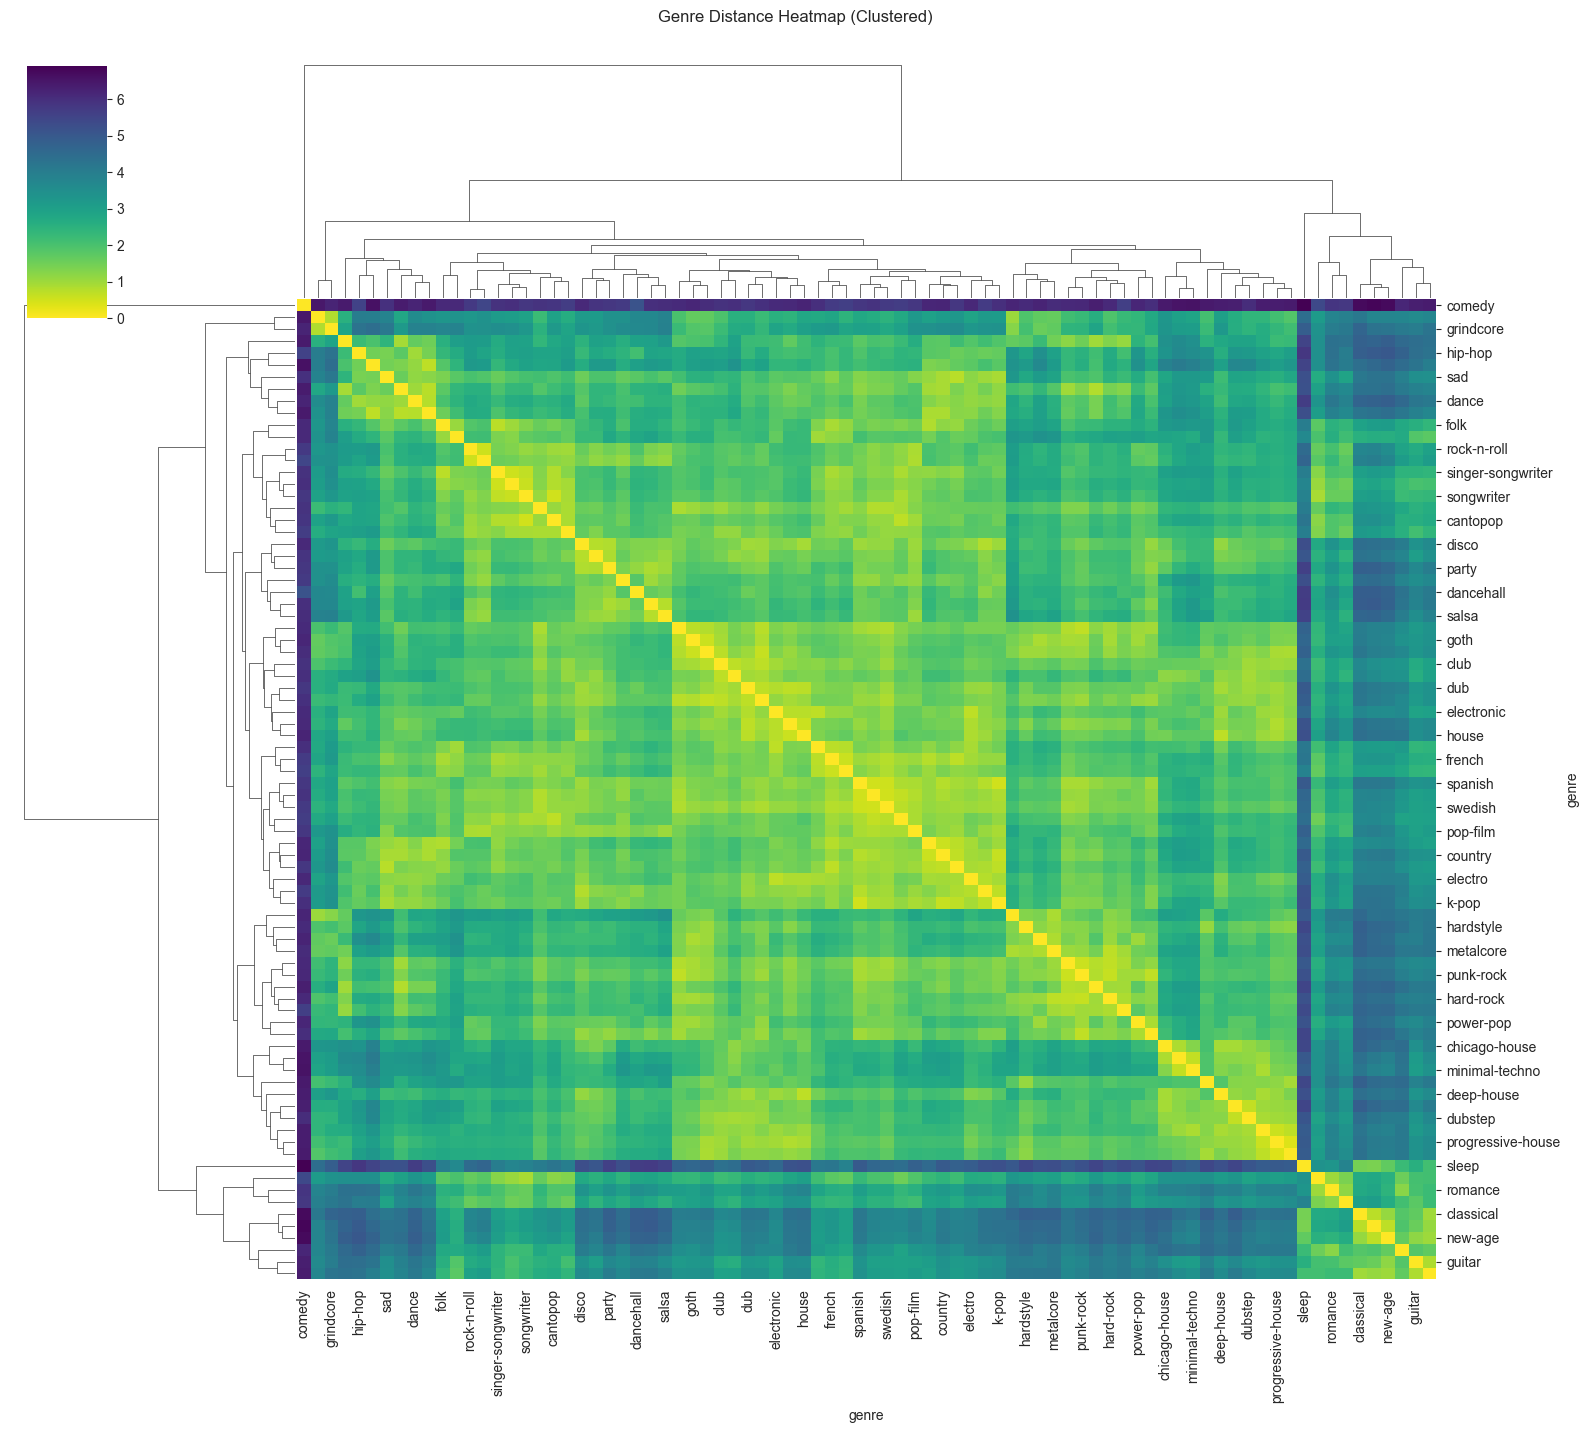

In [43]:
# Heatmap of genre distances
plt.figure(figsize=(16, 14))
g = sns.clustermap(dist_matrix, cmap='viridis_r', figsize=(16, 14))
g.fig.suptitle('Genre Distance Heatmap (Clustered)', y=1.02)
plt.show()

## 5. Feature Importance Analysis

To understand which features discriminate between genres, we use **mutual information**. This helps us:
1. Identify key features for each potential macro-genre
2. Validate that sub-genres share similar feature profiles

In [44]:
# Overall feature importance using mutual information
X_all = data[feature_cols].values
y_all = LabelEncoder().fit_transform(data['genre'])

mi_scores = mutual_info_classif(X_all, y_all, random_state=RANDOM_STATE)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print("FEATURE IMPORTANCE (Mutual Information with Genre)")
print("="*50)
for _, row in feature_importance.iterrows():
    print(f"  {row['feature']:20s}: {row['mutual_info']:.4f}")

FEATURE IMPORTANCE (Mutual Information with Genre)
  acousticness        : 0.4847
  energy              : 0.3553
  popularity          : 0.3448
  instrumentalness    : 0.3238
  tempo               : 0.3236
  danceability        : 0.3045
  loudness            : 0.3009
  valence             : 0.2246
  speechiness         : 0.2070
  liveness            : 0.0910


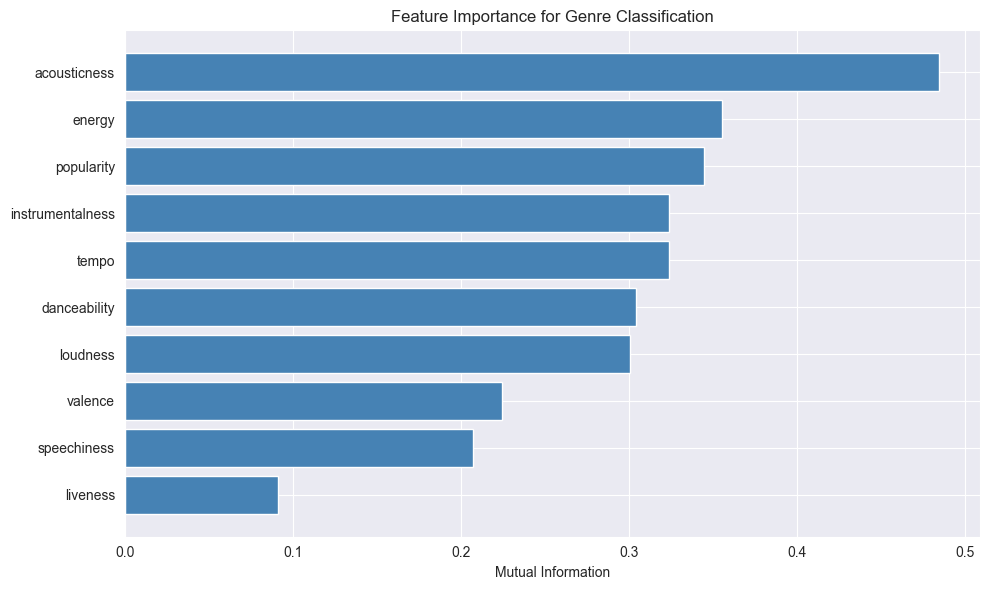

In [45]:
# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['mutual_info'], color='steelblue')
plt.xlabel('Mutual Information')
plt.title('Feature Importance for Genre Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Defining Macro-Genre Categories

Based on domain knowledge, clustering results and feature analysis, we drfine the **macro-genres** that group acoustically similar genres together. Each macro-genre should have a **discriminative feature profile**.

In [46]:
# Define candidate macro-genres based on clustering + domain knowledge
macro_genre_candidates = {
    'Acoustic': ['ambient', 'acoustic', 'chill', 'sleep', 'new-age', 'classical', 'piano', 'guitar', 'opera'],
    'Electronic': ['deep-house', 'minimal-techno', 'drum-and-bass', 'club', 'dance', 'disco', 'techno', 
                   'house', 'edm', 'trance', 'dubstep', 'progressive-house', 'chicago-house', 
                   'detroit-techno', 'electro', 'hardstyle', 'breakbeat', 'garage', 'trip-hop', 
                   'electronic', 'dub'],
    'Hip-Hop': ['hip-hop', 'funk', 'groove', 'soul', 'afrobeat', 'dancehall'],
    'Metal': ['metal', 'black-metal', 'death-metal', 'heavy-metal', 'grindcore', 'hardcore', 
              'industrial', 'goth', 'emo', 'metalcore'],
    'Latin': ['salsa', 'samba', 'sertanejo', 'forro', 'tango', 'spanish'],
    'Rock': ['rock', 'alt-rock', 'hard-rock', 'rock-n-roll', 'punk', 'punk-rock', 'psych-rock', 
             'power-pop', 'ska'],
    'Folk': ['folk', 'country', 'blues', 'singer-songwriter', 'songwriter'],
    'Jazz': ['jazz', 'gospel'],
    'Pop': ['pop', 'pop-film', 'party', 'romance', 'sad', 'show-tunes', 'comedy', 'k-pop', 
            'indie-pop', 'cantopop'],
    'World': ['indian', 'french', 'german', 'swedish']
}

In [47]:
# Analyze feature profiles for each macro-genre candidate
print("MACRO-GENRE FEATURE PROFILES")
print("="*80)

macro_profiles = []

for macro, subgenres in macro_genre_candidates.items():
    # Filter to existing genres
    existing = [g for g in subgenres if g in genre_centroids.index]
    if not existing:
        continue
    
    # Calculate mean profile for this macro-genre
    profile = genre_centroids.loc[existing].mean()
    profile['macro_genre'] = macro
    macro_profiles.append(profile)
    
    print(f"\n{macro} ({len(existing)} sub-genres):")
    top_features = profile[feature_cols].sort_values(ascending=False).head(3)
    for feat, val in top_features.items():
        print(f"  {feat}: {val:.3f}")

macro_profile_df = pd.DataFrame(macro_profiles).set_index('macro_genre')

MACRO-GENRE FEATURE PROFILES

Acoustic (9 sub-genres):
  acousticness: 1.127
  instrumentalness: 0.810
  popularity: -0.097

Electronic (21 sub-genres):
  danceability: 0.567
  instrumentalness: 0.502
  energy: 0.417

Hip-Hop (6 sub-genres):
  danceability: 0.640
  valence: 0.471
  speechiness: 0.325

Metal (10 sub-genres):
  energy: 0.792
  loudness: 0.540
  tempo: 0.152

Latin (6 sub-genres):
  valence: 0.812
  acousticness: 0.513
  danceability: 0.395

Rock (9 sub-genres):
  energy: 0.376
  loudness: 0.373
  valence: 0.295

Folk (5 sub-genres):
  popularity: 0.419
  acousticness: 0.319
  valence: 0.077

Jazz (2 sub-genres):
  acousticness: 0.453
  popularity: 0.396
  danceability: 0.055

Pop (10 sub-genres):
  acousticness: 0.427
  speechiness: 0.411
  danceability: 0.208

World (4 sub-genres):
  acousticness: 0.150
  popularity: 0.093
  speechiness: 0.039


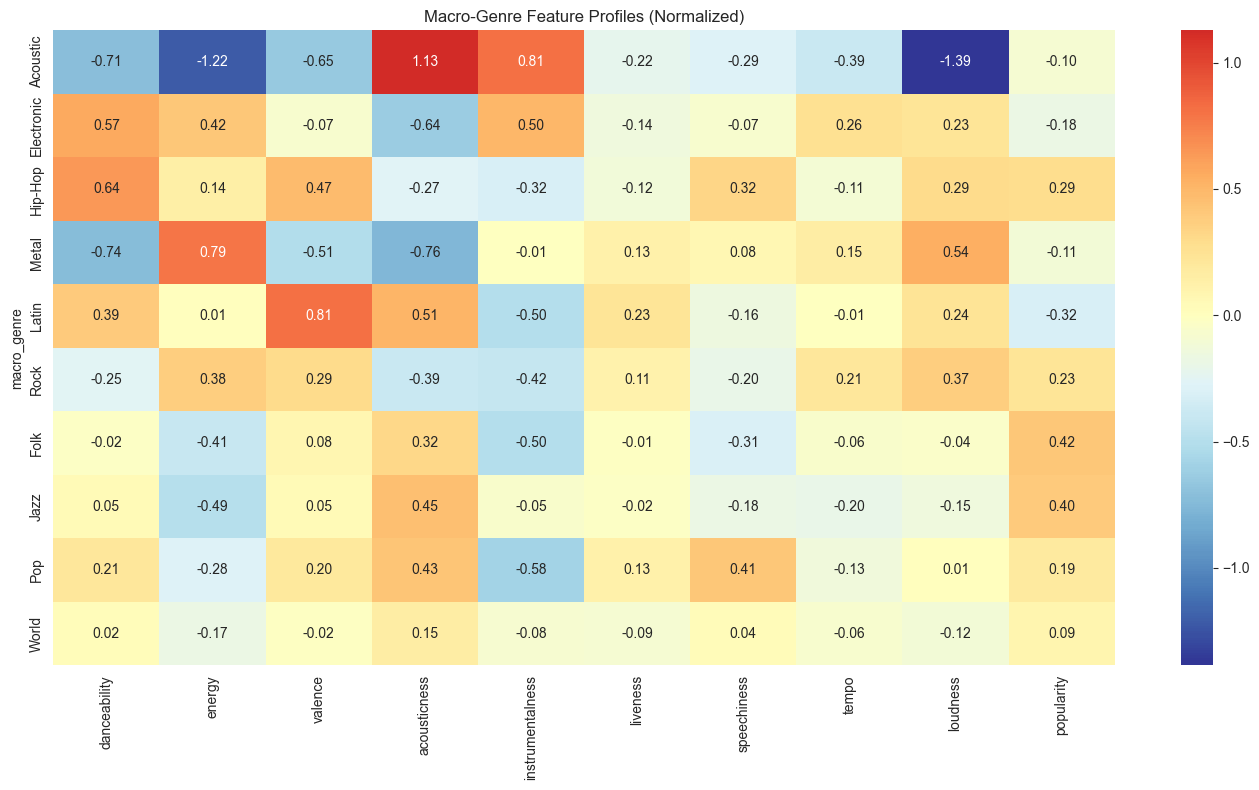

In [48]:
# Visualize macro-genre feature profiles
plt.figure(figsize=(14, 8))
sns.heatmap(macro_profile_df[feature_cols], annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Macro-Genre Feature Profiles (Normalized)')
plt.tight_layout()
plt.show()

## 7. Validating Sub-Genre Membership

For each macro-genre, we identify its **key discriminative feature** using mutual information, then verify that candidate sub-genres share this characteristic.

In [49]:
# Create initial mapping for analysis
genre_mapping_initial = {}
for macro, subgenres in macro_genre_candidates.items():
    for g in subgenres:
        if g in data['genre'].values:
            genre_mapping_initial[g] = macro

data_mapped = data[data['genre'].isin(genre_mapping_initial.keys())].copy()
data_mapped['macro_genre'] = data_mapped['genre'].map(genre_mapping_initial)

print(f"Mapped {len(data_mapped):,} samples to {data_mapped['macro_genre'].nunique()} macro-genres")

Mapped 1,159,748 samples to 10 macro-genres


In [50]:
# Find key discriminative feature for each macro-genre
print("DATA-DRIVEN KEY FEATURES PER MACRO-GENRE")
print("="*60)

key_features = {}

for macro in data_mapped['macro_genre'].unique():
    # Binary classification: this macro-genre vs all others
    y_binary = (data_mapped['macro_genre'] == macro).astype(int)
    X_features = data_mapped[feature_cols].values
    
    mi_scores = mutual_info_classif(X_features, y_binary, random_state=RANDOM_STATE)
    
    feat_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': mi_scores
    }).sort_values('importance', ascending=False)
    
    top_feat = feat_importance.iloc[0]['feature']
    top_score = feat_importance.iloc[0]['importance']
    key_features[macro] = top_feat
    
    print(f"\n{macro}:")
    print(f"  Key feature: {top_feat} (MI={top_score:.4f})")
    print(f"  Top 3: {feat_importance.head(3)['feature'].tolist()}")

DATA-DRIVEN KEY FEATURES PER MACRO-GENRE

Acoustic:
  Key feature: loudness (MI=0.1278)
  Top 3: ['loudness', 'energy', 'acousticness']

Hip-Hop:
  Key feature: danceability (MI=0.0205)
  Top 3: ['danceability', 'speechiness', 'acousticness']

Rock:
  Key feature: instrumentalness (MI=0.0226)
  Top 3: ['instrumentalness', 'danceability', 'acousticness']

Metal:
  Key feature: acousticness (MI=0.0971)
  Top 3: ['acousticness', 'energy', 'danceability']

Folk:
  Key feature: popularity (MI=0.0302)
  Top 3: ['popularity', 'instrumentalness', 'speechiness']

Electronic:
  Key feature: tempo (MI=0.0860)
  Top 3: ['tempo', 'acousticness', 'instrumentalness']

Pop:
  Key feature: instrumentalness (MI=0.0485)
  Top 3: ['instrumentalness', 'speechiness', 'acousticness']

Latin:
  Key feature: valence (MI=0.0359)
  Top 3: ['valence', 'acousticness', 'instrumentalness']

World:
  Key feature: instrumentalness (MI=0.0106)
  Top 3: ['instrumentalness', 'popularity', 'energy']

Jazz:
  Key feature: 

In [51]:
# Validate Hip-Hop sub-genres using speechiness
print("\nHIP-HOP SUB-GENRE VALIDATION (key feature: speechiness)")
print("="*60)

hiphop_candidates = ['hip-hop', 'funk', 'groove', 'soul', 'afrobeat', 'dancehall', 'trip-hop']
threshold = 0.10  # Based on feature distribution analysis

for g in hiphop_candidates:
    subset = data[data['genre'] == g]
    if len(subset) > 0:
        mean_speech = subset['speechiness'].mean()
        include = "INCLUDE" if mean_speech > threshold else "EXCLUDE"
        print(f"  {g:15s}: speechiness={mean_speech:.3f}  -> {include}")


HIP-HOP SUB-GENRE VALIDATION (key feature: speechiness)
  hip-hop        : speechiness=0.917  -> INCLUDE
  funk           : speechiness=0.205  -> INCLUDE
  groove         : speechiness=-0.097  -> EXCLUDE
  soul           : speechiness=0.032  -> EXCLUDE
  afrobeat       : speechiness=-0.015  -> EXCLUDE
  dancehall      : speechiness=0.907  -> INCLUDE
  trip-hop       : speechiness=-0.103  -> EXCLUDE


## 8. Macro-Genre Separability Analysis

After defining macro-genres, we analyze their separability to identify potential problem areas.

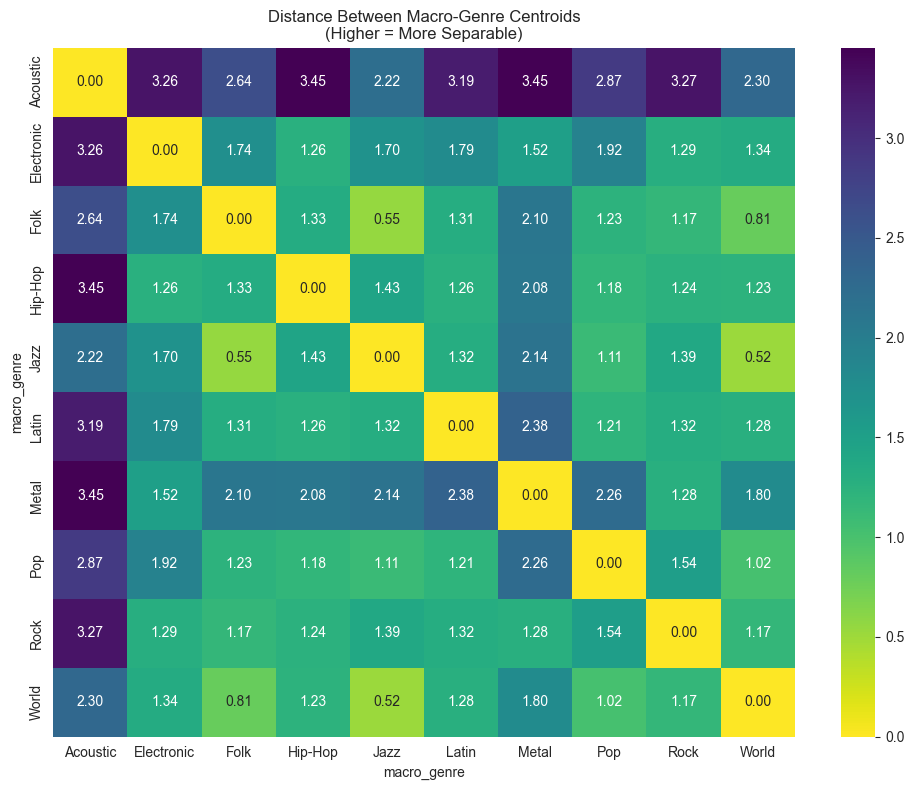

In [52]:
# Calculate macro-genre centroids
macro_centroids = data_mapped.groupby('macro_genre')[feature_cols].mean()

# Distance matrix between macro-genres
macro_dist_matrix = pd.DataFrame(
    squareform(pdist(macro_centroids)),
    index=macro_centroids.index,
    columns=macro_centroids.index
)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(macro_dist_matrix, annot=True, fmt='.2f', cmap='viridis_r')
plt.title('Distance Between Macro-Genre Centroids\n(Higher = More Separable)')
plt.tight_layout()
plt.show()

In [53]:
# Separability ranking
print("MACRO-GENRE SEPARABILITY ANALYSIS")
print("="*60)

avg_dist = macro_dist_matrix.mean(axis=1).sort_values(ascending=False)
print("\nAverage distance to other genres (higher = more unique):")
for genre, dist in avg_dist.items():
    print(f"  {genre:15s}: {dist:.4f}")

# Find problematic pairs
pairs = []
for g1 in macro_dist_matrix.index:
    for g2 in macro_dist_matrix.columns:
        if g1 < g2:
            pairs.append((g1, g2, macro_dist_matrix.loc[g1, g2]))

print("\nClosest macro-genre pairs (may need merging):")
for g1, g2, d in sorted(pairs, key=lambda x: x[2])[:5]:
    print(f"  {g1:15s} <-> {g2:15s}: {d:.4f}")

print("\nFarthest macro-genre pairs (naturally separable):")
for g1, g2, d in sorted(pairs, key=lambda x: x[2], reverse=True)[:5]:
    print(f"  {g1:15s} <-> {g2:15s}: {d:.4f}")

MACRO-GENRE SEPARABILITY ANALYSIS

Average distance to other genres (higher = more unique):
  Acoustic       : 2.6655
  Metal          : 1.9003
  Electronic     : 1.5824
  Latin          : 1.5063
  Hip-Hop        : 1.4479
  Pop            : 1.4331
  Rock           : 1.3663
  Folk           : 1.2885
  Jazz           : 1.2378
  World          : 1.1473

Closest macro-genre pairs (may need merging):
  Jazz            <-> World          : 0.5212
  Folk            <-> Jazz           : 0.5488
  Folk            <-> World          : 0.8062
  Pop             <-> World          : 1.0214
  Jazz            <-> Pop            : 1.1108

Farthest macro-genre pairs (naturally separable):
  Acoustic        <-> Hip-Hop        : 3.4523
  Acoustic        <-> Metal          : 3.4472
  Acoustic        <-> Rock           : 3.2722
  Acoustic        <-> Electronic     : 3.2638
  Acoustic        <-> Latin          : 3.1929


## 9. Visualization: PCA and t-SNE

We visualize the macro-genre separability using dimensionality reduction techniques.

In [54]:
# Sample for visualization speed
sample_size = 3000
X_sample = (
    data_mapped
    .groupby('macro_genre', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), sample_size), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f"Sample size: {len(X_sample):,}")
print(X_sample['macro_genre'].value_counts())

Sample size: 30,000
macro_genre
Acoustic      3000
Electronic    3000
Folk          3000
Hip-Hop       3000
Jazz          3000
Latin         3000
Metal         3000
Pop           3000
Rock          3000
World         3000
Name: count, dtype: int64


/var/folders/7v/bc31x96s2dj6mmrryly2sdqc0000gn/T/ipykernel_64131/551797940.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), sample_size), random_state=RANDOM_STATE))


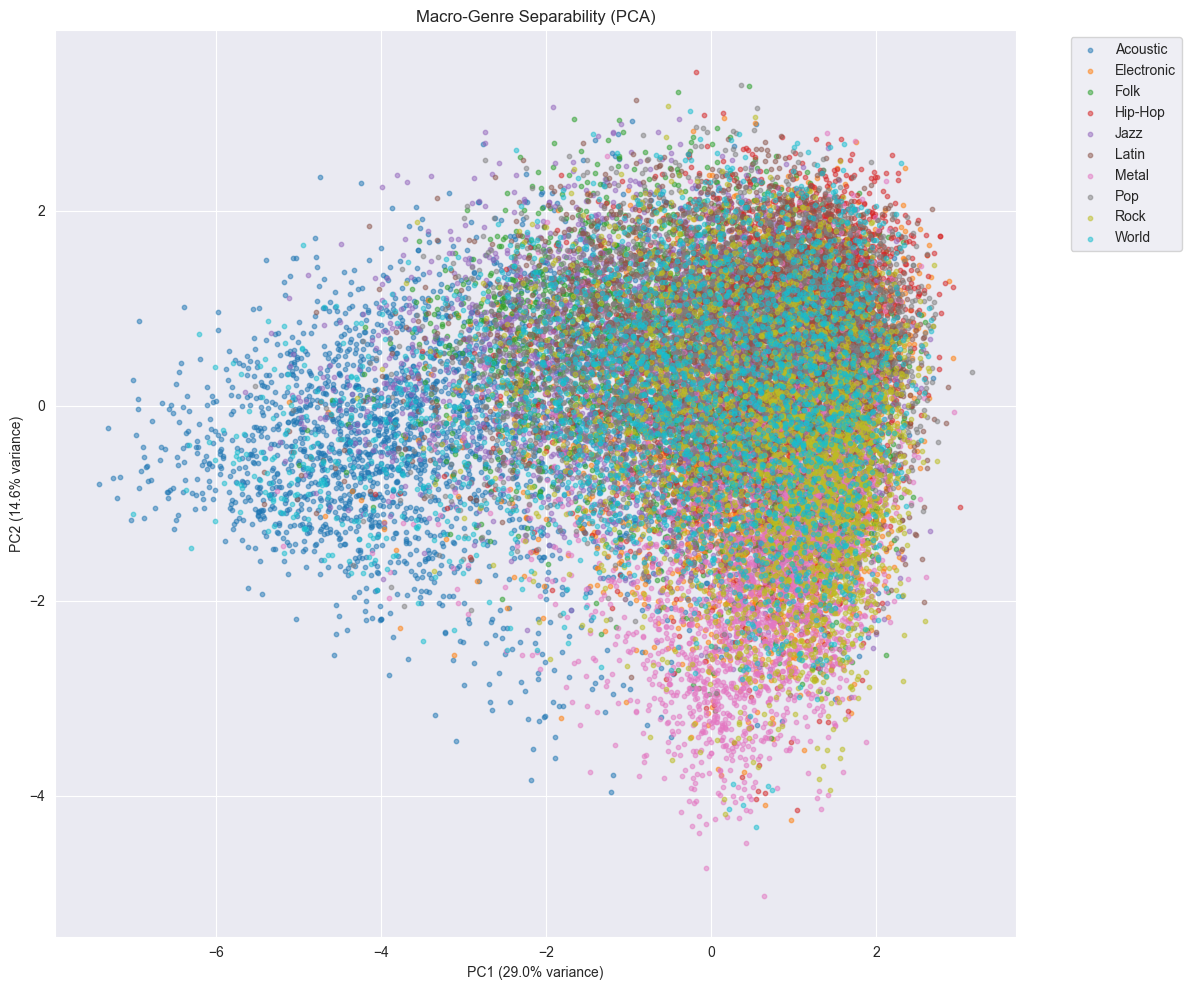

In [55]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample[feature_cols])

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 10))
for macro in X_sample['macro_genre'].unique():
    mask = X_sample['macro_genre'] == macro
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=macro, alpha=0.5, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Macro-Genre Separability (PCA)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Running t-SNE...


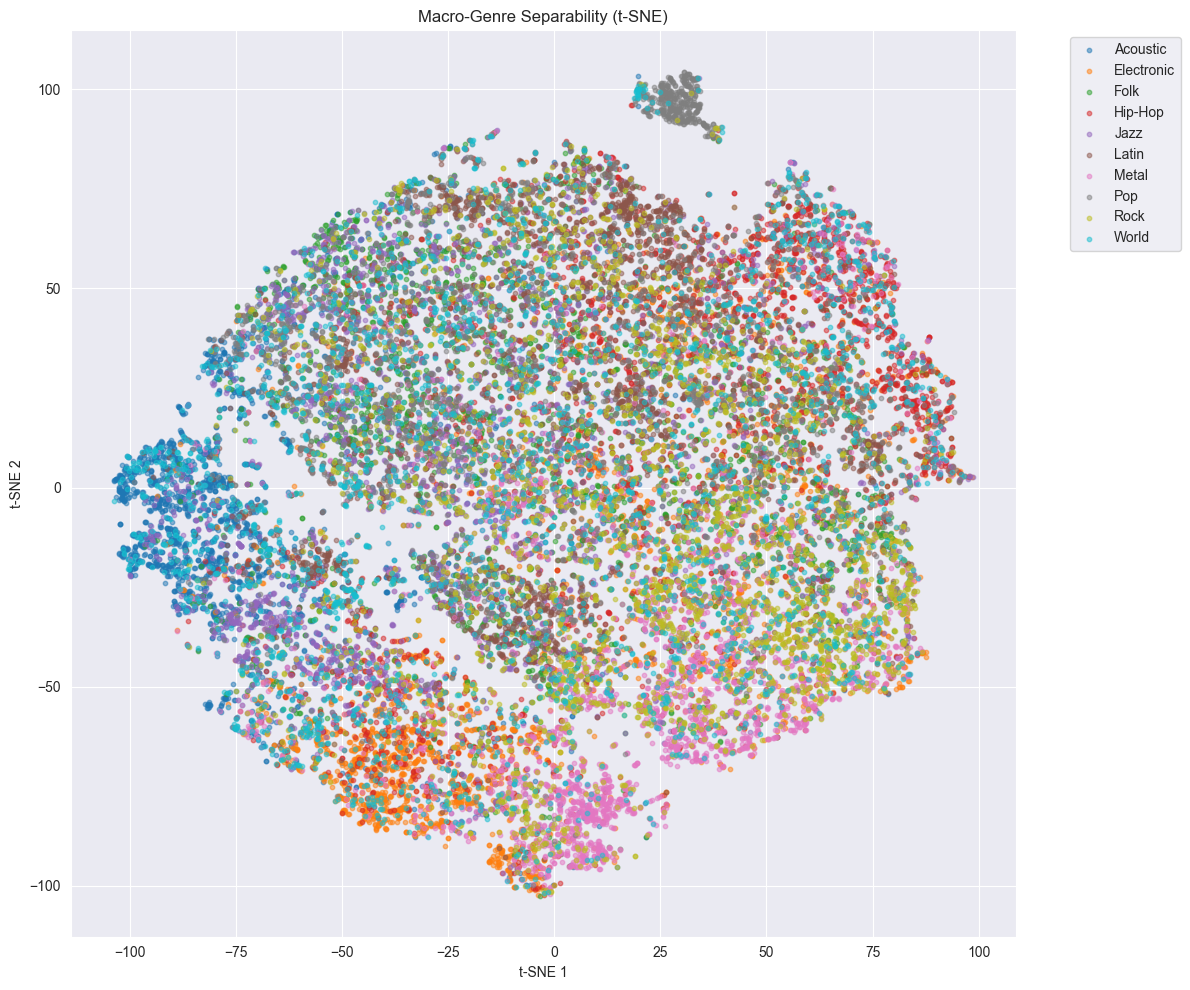

In [56]:
# t-SNE (takes 1-2 minutes)
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 10))
for macro in X_sample['macro_genre'].unique():
    mask = X_sample['macro_genre'] == macro
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=macro, alpha=0.5, s=10)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Macro-Genre Separability (t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Final Macro-Genres for Classification

Based on our analysis, we create the final mapping. Key decisions:

1. **Keep Hip-Hop pure** - Only `hip-hop` genre (high speechiness)
2. **Merge and drop Jazz + Folk + World** - Too similar to separate (distance < 0.6)
3. **Drop Rock and Pop** - Overlap with multiple categories

In [57]:
# Final optimized mapping based on separability analysis
genre_mapping_final = {
    # Acoustic - highest separability, high acousticness
    'ambient': 'Acoustic',
    'acoustic': 'Acoustic',
    'chill': 'Acoustic',
    'sleep': 'Acoustic',
    'new-age': 'Acoustic',
    'classical': 'Acoustic',
    'piano': 'Acoustic',
    'guitar': 'Acoustic',
    'opera': 'Acoustic',

    # Electronic - low acousticness, high danceability
    'deep-house': 'Electronic',
    'minimal-techno': 'Electronic',
    'drum-and-bass': 'Electronic',
    'club': 'Electronic',
    'dance': 'Electronic',
    'disco': 'Electronic',
    'techno': 'Electronic',
    'house': 'Electronic',
    'edm': 'Electronic',
    'trance': 'Electronic',
    'dubstep': 'Electronic',
    'progressive-house': 'Electronic',
    'chicago-house': 'Electronic',
    'detroit-techno': 'Electronic',
    'electro': 'Electronic',
    'hardstyle': 'Electronic',
    'breakbeat': 'Electronic',
    'garage': 'Electronic',
    'trip-hop': 'Electronic',
    'electronic': 'Electronic',
    'dub': 'Electronic',

    # Hip-Hop - ONLY pure hip-hop, key: high speechiness
    'hip-hop': 'Hip-Hop',

    # Metal - high energy, high loudness
    'metal': 'Metal',
    'black-metal': 'Metal',
    'death-metal': 'Metal',
    'heavy-metal': 'Metal',
    'grindcore': 'Metal',
    'hardcore': 'Metal',
    'industrial': 'Metal',
    'goth': 'Metal',
    'emo': 'Metal',
    'metalcore': 'Metal',

    # Latin - high danceability, distinctive rhythm
    'salsa': 'Latin',
    'samba': 'Latin',
    'sertanejo': 'Latin',
    'forro': 'Latin',
    'tango': 'Latin',
    'spanish': 'Latin',
}

print(f"Final mapping: {len(genre_mapping_final)} sub-genres -> 5 macro-genres")

Final mapping: 47 sub-genres -> 5 macro-genres


In [58]:
# Apply final mapping
data_final = data[data['genre'].isin(genre_mapping_final.keys())].copy()
data_final['macro_genre'] = data_final['genre'].map(genre_mapping_final)

print("FINAL MACRO-GENRE DISTRIBUTION")
print("="*40)
print(data_final['macro_genre'].value_counts())
print(f"\nTotal samples: {len(data_final):,}")

FINAL MACRO-GENRE DISTRIBUTION
macro_genre
Electronic    247053
Acoustic      163542
Metal         151997
Latin         107272
Hip-Hop        15703
Name: count, dtype: int64

Total samples: 685,567


In [59]:
# Export final dataset
data_final.to_csv("../data/processed/final_dataset.csv", index=False)
print("Exported to ../data/processed/final_dataset.csv")

OSError: Cannot save file into a non-existent directory: '../data/processed'

## 11. Summary

### Methodology

1. **Hierarchical clustering** on genre centroids revealed natural groupings
2. **Pairwise distance analysis** identified similar/distinct genre pairs
3. **Mutual information** determined key discriminative features per macro-genre
4. **Sub-genre validation** ensured members share the key feature profile
5. **Separability analysis** guided decisions on merging/dropping categories

### Final Macro-Genres

| Macro-Genre | Key Feature | Sub-genres |
|-------------|-------------|------------|
| Acoustic | acousticness (high) | ambient, classical, chill, sleep, etc. |
| Electronic | acousticness (low) | edm, house, techno, trance, etc. |
| Hip-Hop | speechiness (high) | hip-hop only |
| Metal | energy (high) | metal, black-metal, death-metal, etc. |
| Latin | danceability (high) | salsa, samba, tango, etc. |

### Excluded Categories

- **Rock, Pop, Folk, Jazz, World**: Low separability (distance < 1.2), high overlap with other categories